# Setup Environment

In [78]:
# Automatically reload external Python modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [79]:
# imports
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay
import nltk
from nltk.corpus import cmudict

import Functions.load_datasets as load_datasets
import Functions.process_dataset as process_dataset
import Functions.plot_ROC as plot_roc
import Functions.by_card_by_person as by_card_by_person

# Generate Datasets

In [80]:
datasets = load_datasets.load(noun_acc_dataset_train = 'Datasets/Generalization Train DataLong NounAcc.xlsx', 
                            clinical_dataset_train = 'Datasets/Generalization Train Clinical Dataset.xlsx',
                            linguistic_dataset_train = 'Datasets/Generalization Train Linguistics Dataset Adjusted Simple.xlsx',
                            networks_dataset_train = 'Datasets/Generalization Train Network Strength Dataset.xlsx',
                            noun_acc_dataset_new = 'Datasets/Generalization Test new pts new cards DataLong NounAcc only.xlsx',
                            clinical_dataset_new = 'Datasets/Generalization Test new patients Clinical Stroke Dataset.xlsx',
                            linguistic_dataset_new = 'Datasets/Generalization Test new cards Linguistics Dataset Adjusted Simple.xlsx',
                            networks_dataset_new = 'Datasets/Generalization Test new patients Network Strength Dataset.xlsx')

noun_acc_dataset_train = datasets['noun_acc_dataset_train']
clinical_dataset_train = datasets['clinical_dataset_train']
linguistic_dataset_train = datasets['linguistic_dataset_train']
networks_dataset_train = datasets['networks_dataset_train']
noun_acc_dataset_new = datasets['noun_acc_dataset_new']
clinical_dataset_new = datasets['clinical_dataset_new']
linguistic_dataset_new = datasets['linguistic_dataset_new']
networks_dataset_new = datasets['networks_dataset_new']


Loaded Datasets/Generalization Train DataLong NounAcc.xlsx, shape: (4620, 7)
Loaded Datasets/Generalization Train Clinical Dataset.xlsx, shape: (35, 20)
Loaded Datasets/Generalization Train Linguistics Dataset Adjusted Simple.xlsx, shape: (66, 8)
Loaded Datasets/Generalization Train Network Strength Dataset.xlsx, shape: (35, 84)
Loaded Datasets/Generalization Test new pts new cards DataLong NounAcc only.xlsx, shape: (1284, 7)
Loaded Datasets/Generalization Test new patients Clinical Stroke Dataset.xlsx, shape: (6, 20)
Loaded Datasets/Generalization Test new cards Linguistics Dataset Adjusted Simple.xlsx, shape: (6, 9)
Loaded Datasets/Generalization Test new patients Network Strength Dataset.xlsx, shape: (3, 84)


In [81]:
data_clin_train = pd.merge(noun_acc_dataset_train, clinical_dataset_train, on=["SubjID"])
data_ling_train = pd.merge(noun_acc_dataset_train, linguistic_dataset_train ,on=["Agent_Noun"])
data_nets_train = pd.merge(noun_acc_dataset_train, networks_dataset_train, on=["SubjID"])

# Generate clin_ling training datasets
data_clin_ling_simple_train = pd.merge(data_clin_train, linguistic_dataset_train, on=["Agent_Noun"])

In [82]:
data_clin_new = pd.merge(noun_acc_dataset_new, clinical_dataset_new, on=["SubjID"])
data_ling_new = pd.merge(noun_acc_dataset_new, linguistic_dataset_new, on=["Agent_Noun"])
data_nets_new = pd.merge(noun_acc_dataset_new, networks_dataset_new, on=["SubjID"])

# Generate clin_ling_simple new pts new cards datasets
data_clin_ling_simple_new_pts_new_cards = pd.merge(data_clin_new, linguistic_dataset_new, on=["Agent_Noun"])

In [83]:
# Generate clin_ling_simple: same pts new cards, new pts same cards datasets
data_clin_ling_simple_same_pts_new_cards = pd.merge(noun_acc_dataset_new, clinical_dataset_train, on=["SubjID"])
data_clin_ling_simple_same_pts_new_cards = pd.merge(data_clin_ling_simple_same_pts_new_cards, linguistic_dataset_new, on=["Agent_Noun"])

data_clin_ling_simple_new_pts_same_cards = pd.merge(data_clin_new, linguistic_dataset_train, on=["Agent_Noun"])

In [84]:
X_clin_ling_simple_train, y_clin_ling_simple_train = process_dataset.preprocess_single_dataset_simple(data_clin_ling_simple_train)

X_clin_ling_simple_new_pts_new_cards, y_clin_ling_simple_new_pts_new_cards = process_dataset.preprocess_single_dataset_simple(data_clin_ling_simple_new_pts_new_cards)

X_clin_ling_simple_same_pts_new_cards, y_clin_ling_simple_same_pts_new_cards = process_dataset.preprocess_single_dataset_simple(data_clin_ling_simple_same_pts_new_cards)

X_clin_ling_simple_new_pts_same_cards, y_clin_ling_simple_new_pts_same_cards = process_dataset.preprocess_single_dataset_simple(data_clin_ling_simple_new_pts_same_cards)


X shape: (4620, 9)
y shape: (4620,)
Missing values in X: 0
X shape: (72, 9)
y shape: (72,)
Missing values in X: 0
X shape: (420, 9)
y shape: (420,)
Missing values in X: 0
X shape: (792, 9)
y shape: (792,)
Missing values in X: 0


# Load Models

In [85]:
clin_ling_simple_rf_best_model = joblib.load('saved_models/simple_rf_best_model.joblib')

# Testing Clin + Ling SIMPLE

## Test clin_ling_simple model - new patients new cards

In [86]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_simple_rf_best_model,
    X = X_clin_ling_simple_new_pts_new_cards,
    y = y_clin_ling_simple_new_pts_new_cards,
    data_with_meta = data_clin_ling_simple_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="new_pts_new_cards_by_person.xlsx",
    out_card_excel="new_pts_new_cards_by_card.xlsx"
)


Saved: new_pts_new_cards_by_person.xlsx
Saved: new_pts_new_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Test clin_ling_simple model - same patients new cards

In [87]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_simple_rf_best_model,
    X = X_clin_ling_simple_same_pts_new_cards,
    y = y_clin_ling_simple_same_pts_new_cards,
    data_with_meta = data_clin_ling_simple_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="same_pts_new_cards_by_person.xlsx",
    out_card_excel="same_pts_new_cards_by_card.xlsx"
)


Saved: same_pts_new_cards_by_person.xlsx
Saved: same_pts_new_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

## Test clin_ling_model - new patients same cards

In [88]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_simple_rf_best_model,
    X = X_clin_ling_simple_new_pts_same_cards,
    y = y_clin_ling_simple_new_pts_same_cards,
    data_with_meta = data_clin_ling_simple_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="new_pts_same_cards_by_person.xlsx",
    out_card_excel="new_pts_same_cards_by_card.xlsx"
)


Saved: new_pts_same_cards_by_person.xlsx
Saved: new_pts_same_cards_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

# ROC curves for SIMPLE generalization

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all m

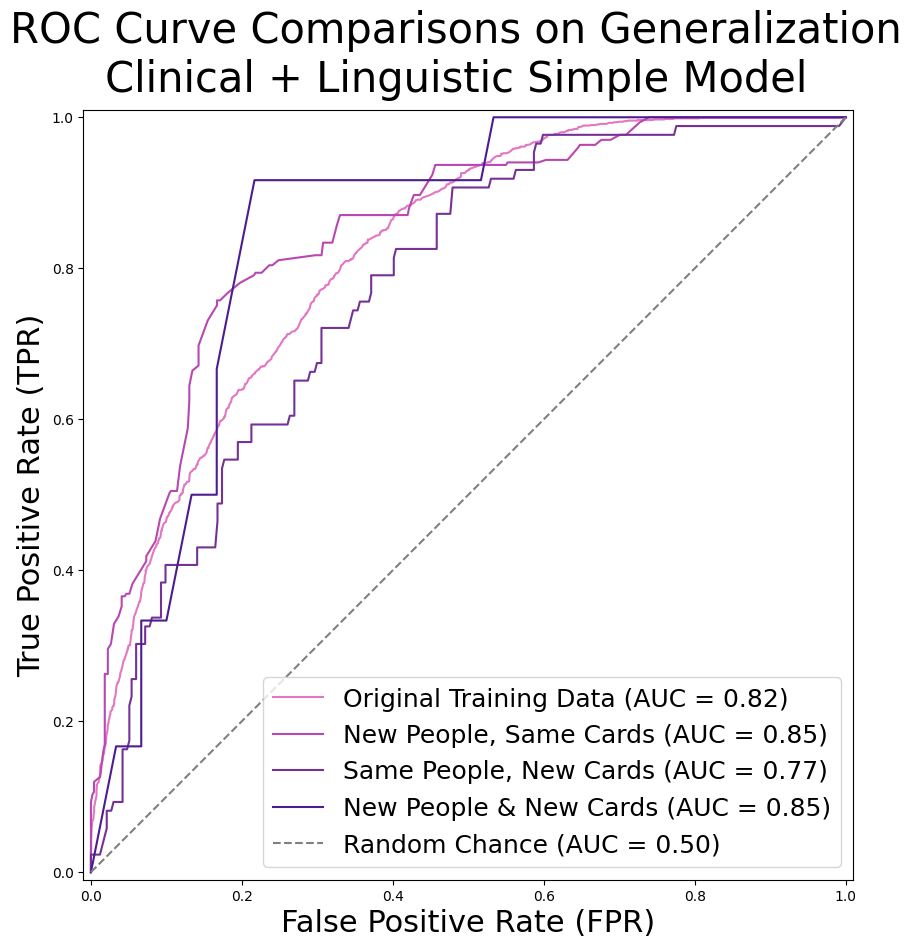

In [89]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot ROC curves on the same axis
clin_ling_simple_disp = RocCurveDisplay.from_estimator(
    clin_ling_simple_rf_best_model, X_clin_ling_simple_train, y_clin_ling_simple_train, color='tab:pink', ax=ax
)
same_cards_disp = RocCurveDisplay.from_estimator(
    clin_ling_simple_rf_best_model, X_clin_ling_simple_new_pts_same_cards, y_clin_ling_simple_new_pts_same_cards, 
    ax=ax, color='#b947b1'
)
same_pts_disp = RocCurveDisplay.from_estimator(
    clin_ling_simple_rf_best_model, X_clin_ling_simple_same_pts_new_cards, y_clin_ling_simple_same_pts_new_cards, 
    ax=ax, color='#743296'
)
all_new_disp = RocCurveDisplay.from_estimator(
    clin_ling_simple_rf_best_model, X_clin_ling_simple_new_pts_new_cards, y_clin_ling_simple_new_pts_new_cards, 
    ax=ax, color='#4d1c91'
)

# Add random chance line
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Chance')

# Extract handles and create custom labels with AUC
handles, _ = ax.get_legend_handles_labels()
labels = [
    f'Original Training Data (AUC = {clin_ling_simple_disp.roc_auc:.2f})',
    f'New People, Same Cards (AUC = {same_cards_disp.roc_auc:.2f})',
    f'Same People, New Cards (AUC = {same_pts_disp.roc_auc:.2f})',
    f'New People & New Cards (AUC = {all_new_disp.roc_auc:.2f})',
    'Random Chance (AUC = 0.50)'
]

# Add legend and labels
ax.legend(handles, labels, loc='lower right', fontsize=18)
ax.set_xlabel('False Positive Rate (FPR)', fontsize=22)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=22)
fig.suptitle("ROC Curve Comparisons on Generalization\nClinical + Linguistic Simple Model", fontsize=30)
plt.show()


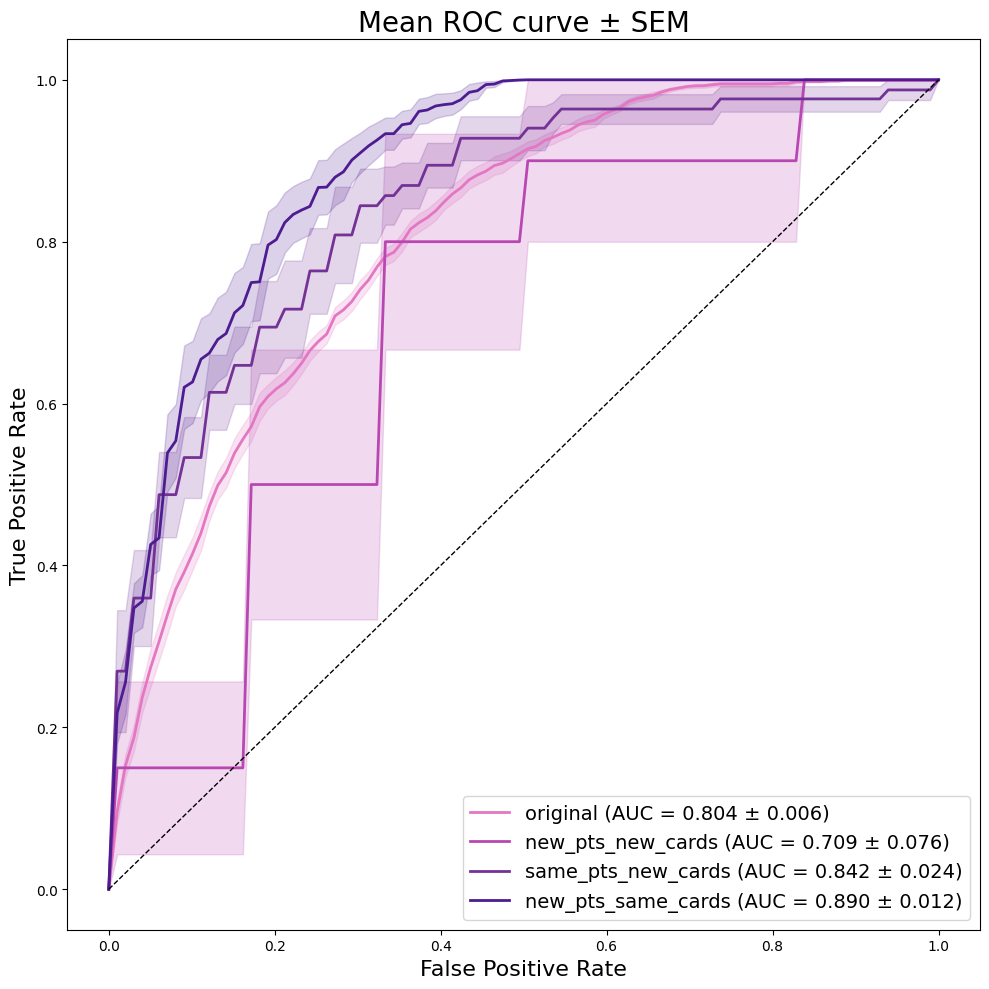

In [90]:
models_dict = {
    'original': clin_ling_simple_rf_best_model,
    'new_pts_new_cards': clin_ling_simple_rf_best_model,
    'same_pts_new_cards': clin_ling_simple_rf_best_model,
    'new_pts_same_cards': clin_ling_simple_rf_best_model
}

X_dict = {
    'original': X_clin_ling_simple_train,
    'new_pts_new_cards': X_clin_ling_simple_new_pts_new_cards,
    'same_pts_new_cards': X_clin_ling_simple_same_pts_new_cards,
    'new_pts_same_cards': X_clin_ling_simple_new_pts_same_cards
}


y_dict = {
    'original': y_clin_ling_simple_train,
    'new_pts_new_cards': y_clin_ling_simple_new_pts_new_cards,
    'same_pts_new_cards': y_clin_ling_simple_same_pts_new_cards,
    'new_pts_same_cards': y_clin_ling_simple_new_pts_same_cards
}




plot_roc.plot_mean_rf_roc_sem(models_dict, X_dict, y_dict, n_splits=10)



# PNT

# Generate Datasets

In [91]:
top_5000_words = pd.read_excel('Datasets/word frequency top 5000.xlsx')
PNT_dataset = pd.read_csv('Datasets/TMSA_PNT.csv')
data_clin_ling_simple_PNT_same_pts = pd.merge(PNT_dataset, clinical_dataset_train, on=["SubjID"])
data_clin_ling_simple_PNT_new_pts = pd.merge(PNT_dataset, clinical_dataset_new, on=["SubjID"])

In [92]:
# baseline data only
data_clin_ling_simple_PNT_same_pts = data_clin_ling_simple_PNT_same_pts[data_clin_ling_simple_PNT_same_pts["TimePoint"] == "Baseline"].copy()

# Rename 'Freq' column to 'Freq_Cond'
data_clin_ling_simple_PNT_same_pts = data_clin_ling_simple_PNT_same_pts.rename(columns={"Freq": "Freq_Cond"})

# Rename 'Acc_Bin' column to 'Freq_Cond'
data_clin_ling_simple_PNT_same_pts = data_clin_ling_simple_PNT_same_pts.rename(columns={"Acc_Bin": "Noun_Acc"})

# Remove extra 'LesionVolume'
data_clin_ling_simple_PNT_same_pts = data_clin_ling_simple_PNT_same_pts.drop(columns=['LesionVolume'])

# Rename 'Syll' column to '	Syllables_avg (SyllaPy)'
data_clin_ling_simple_PNT_same_pts = data_clin_ling_simple_PNT_same_pts.rename(columns={"Syll": "Syllables_avg (SyllaPy)"})

# Rename 'Phonemes' column to 'Phonemes_avg (SyllaPy)'
data_clin_ling_simple_PNT_same_pts = data_clin_ling_simple_PNT_same_pts.rename(columns={"Item": "Agent_Noun"})

# Fix high and low frequency conditions
top_words = set(top_5000_words["word"].str.lower())
data_clin_ling_simple_PNT_same_pts["Freq_Cond"] = data_clin_ling_simple_PNT_same_pts["Agent_Noun"].str.lower().apply(
    lambda x: "HF" if x in top_words else "LF"
)
data_clin_ling_simple_PNT_same_pts["Freq_Cond"].value_counts()


Freq_Cond
HF    2850
LF    1525
Name: count, dtype: int64

In [93]:
# baseline data only
data_clin_ling_simple_PNT_new_pts = data_clin_ling_simple_PNT_new_pts[data_clin_ling_simple_PNT_new_pts["TimePoint"] == "Baseline"].copy()

# Rename 'Freq' column to 'Freq_Cond'
data_clin_ling_simple_PNT_new_pts = data_clin_ling_simple_PNT_new_pts.rename(columns={"Freq": "Freq_Cond"})

# Rename 'Acc_Bin' column to 'Freq_Cond'
data_clin_ling_simple_PNT_new_pts = data_clin_ling_simple_PNT_new_pts.rename(columns={"Acc_Bin": "Noun_Acc"})

# Remove extra 'LesionVolume'
data_clin_ling_simple_PNT_new_pts = data_clin_ling_simple_PNT_new_pts.drop(columns=['LesionVolume'])

# Rename 'Syll' column to '	Syllables_avg (SyllaPy)'
data_clin_ling_simple_PNT_new_pts = data_clin_ling_simple_PNT_new_pts.rename(columns={"Syll": "Syllables_avg (SyllaPy)"})

# Rename 'Phonemes' column to 'Phonemes_avg (SyllaPy)'
data_clin_ling_simple_PNT_new_pts = data_clin_ling_simple_PNT_new_pts.rename(columns={"Item": "Agent_Noun"})

# Fix high and low frequency conditions
top_words = set(top_5000_words["word"].str.lower())
data_clin_ling_simple_PNT_new_pts["Freq_Cond"] = data_clin_ling_simple_PNT_new_pts["Agent_Noun"].str.lower().apply(
    lambda x: "HF" if x in top_words else "LF"
)
data_clin_ling_simple_PNT_new_pts["Freq_Cond"].value_counts()


Freq_Cond
HF    570
LF    305
Name: count, dtype: int64

In [94]:
import nltk
nltk.download('cmudict')

cmu_dict = cmudict.dict()

def count_phonemes(word):
    word = str(word).lower()  # CMUdict keys are lowercase
    if word in cmu_dict:
        # Some words have multiple pronunciations; take the first
        return len(cmu_dict[word][0])
    else:
        # If word not found, estimate phonemes (half the letters, at least 1)
        return max(1, len(word) // 2)

data_clin_ling_simple_PNT_same_pts["Phonemes_avg (CMUDict)"] = data_clin_ling_simple_PNT_same_pts["Agent_Noun"].apply(count_phonemes)
data_clin_ling_simple_PNT_new_pts["Phonemes_avg (CMUDict)"] = data_clin_ling_simple_PNT_new_pts["Agent_Noun"].apply(count_phonemes)


[nltk_data] Downloading package cmudict to
[nltk_data]     /Users/arnavgupta/nltk_data...
[nltk_data]   Package cmudict is already up-to-date!


In [95]:
# Generate X_
X_clin_ling_simple_PNT_same_pts, y_clin_ling_simple_PNT_same_pts = process_dataset.preprocess_single_dataset_simple(data_clin_ling_simple_PNT_same_pts)
X_clin_ling_simple_PNT_new_pts, y_clin_ling_simple_PNT_new_pts = process_dataset.preprocess_single_dataset_simple(data_clin_ling_simple_PNT_new_pts)

# Reorder the columns
X_clin_ling_simple_PNT_same_pts = X_clin_ling_simple_PNT_same_pts[X_clin_ling_simple_train.columns]
X_clin_ling_simple_PNT_new_pts = X_clin_ling_simple_PNT_new_pts[X_clin_ling_simple_train.columns]

X shape: (4375, 9)
y shape: (4375,)
Missing values in X: 0
X shape: (875, 9)
y shape: (875,)
Missing values in X: 0


# By Persons & By Cards

In [96]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_simple_rf_best_model,
    X = X_clin_ling_simple_PNT_same_pts,
    y = y_clin_ling_simple_PNT_same_pts,
    data_with_meta = data_clin_ling_simple_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="PNT_same_pts_by_person.xlsx",
    out_card_excel="PNT_same_pts_by_card.xlsx"
)


Saved: PNT_same_pts_by_person.xlsx
Saved: PNT_same_pts_by_card.xlsx


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [97]:
by_card_by_person.save_breakdowns_by_person_card(
    model = clin_ling_simple_rf_best_model,
    X = X_clin_ling_simple_PNT_new_pts,
    y = y_clin_ling_simple_PNT_new_pts,
    data_with_meta = data_clin_ling_simple_new_pts_new_cards,
    person_col="SubjID",
    card_col="Agent_Noun",
    out_person_excel="PNT_new_pts_by_person.xlsx",
    out_card_excel="PNT_new_pts_by_card.xlsx"
)


Saved: PNT_new_pts_by_person.xlsx
Saved: PNT_new_pts_by_card.xlsx


# Plot ROC

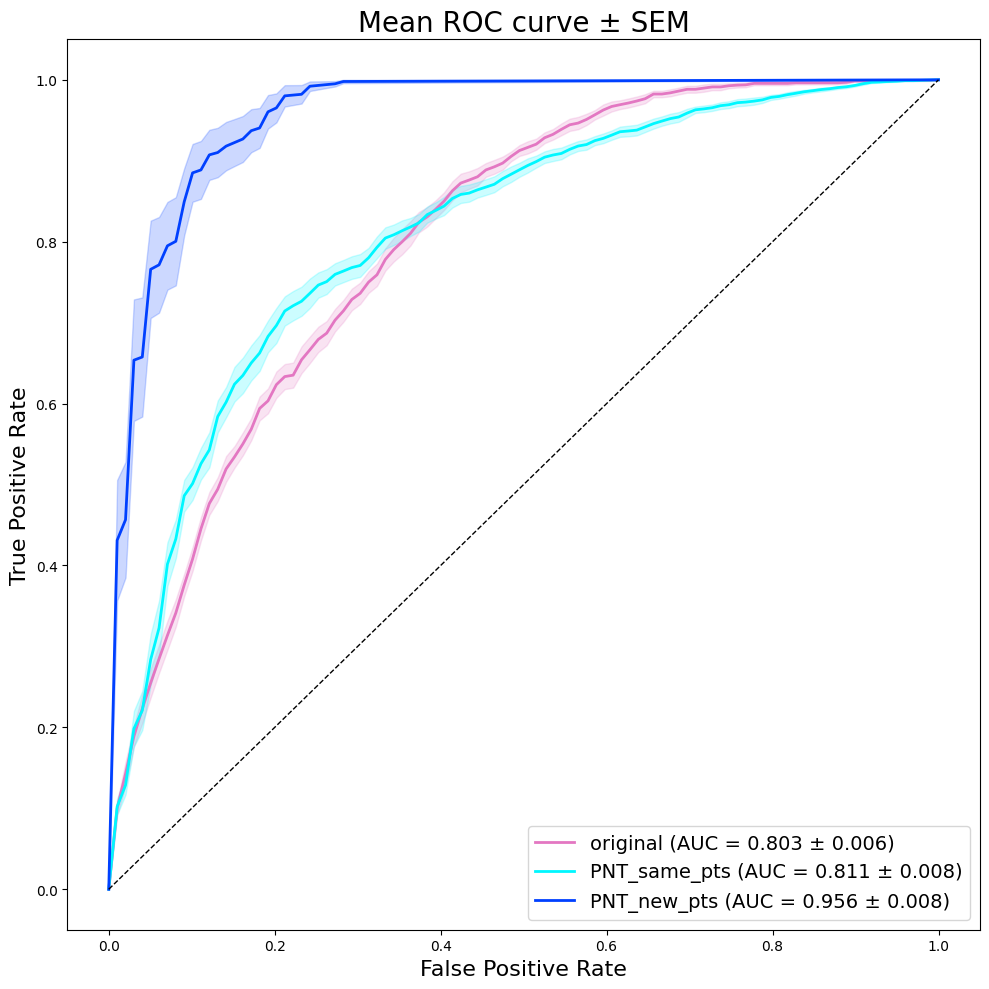

In [98]:
models_dict = {
    'original': clin_ling_simple_rf_best_model,
    'PNT_same_pts': clin_ling_simple_rf_best_model,
    'PNT_new_pts': clin_ling_simple_rf_best_model
}

X_dict = {
    'original': X_clin_ling_simple_train,
    'PNT_same_pts': X_clin_ling_simple_PNT_same_pts,
    'PNT_new_pts': X_clin_ling_simple_PNT_new_pts
}


y_dict = {
    'original': y_clin_ling_simple_train,
    'PNT_same_pts': y_clin_ling_simple_PNT_same_pts,
    'PNT_new_pts': y_clin_ling_simple_PNT_new_pts

}

plot_roc.plot_mean_rf_roc_sem(models_dict, X_dict, y_dict, n_splits=10, colors=['tab:pink', "#00F7FF", '#0040FF'])

